In [2]:
# 03_model_comparison
#
# 목적: 2017-01-31까지 관측된 동일 피처로 LightGBM 외 4개 모델
#      (XGBoost, CatBoost, RandomForest, Logistic Regression)을 학습해 성능을 비교한다.
#
# 원칙 (기존 단계와 동일):
#   - 각 모델의 threshold는 valid에서 결정하고 test에는 그대로 적용
#   - test 결과를 확인한 뒤 추가 튜닝하지 않음
#   - 원-핫 인코더/스케일러는 train으로만 fit
#   - 이번 비교 단계는 Optuna 풀 튜닝 없이 합리적 기본값 + early stopping으로 기준선만 확보
#
# 범주형 처리:
#   - LightGBM/XGBoost/CatBoost: 네이티브 카테고리 처리
#   - RandomForest/LogisticRegression: 원-핫 인코딩 (train fit) + LogisticRegression만 StandardScaler 추가
#
# 입력: data/processed/model_table_final.csv, models/lightgbm_final.txt (기존 결과 재사용)
# 출력: models/{xgboost,catboost,randomforest,logreg}_final.*, models/model_comparison.csv

In [3]:
import json
import numpy as np
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, log_loss, average_precision_score,
    precision_recall_curve, precision_recall_fscore_support, confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid", {"grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
plt.rcParams.update({
    "figure.dpi": 110,
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
})
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]

CATEGORICAL_COLS = ["city", "registered_via", "gender"]
DROP_COLS = ["msno", "snapshot", "split", "is_churn"]
RANDOM_STATE = 42

In [4]:
df = pd.read_csv(PROCESSED_DIR / "model_table_final.csv")

# 모델 비교 전에 최종 전처리 결과와 시간 누수 방지 조건을 다시 검증
assert df["snapshot"].eq("2017-01-31").all(), "snapshot 기준일이 2017-01-31이 아닙니다."
assert df.isna().sum().sum() == 0, "최종 테이블에 결측치가 있습니다."
assert df["msno"].duplicated().sum() == 0, "사용자 중복이 있습니다."
assert (df["days_since_last_txn"] < 0).sum() == 0, "관측 종료일 이후 거래가 포함됐습니다."
# city/registered_via가 CSV round-trip 과정에서 float64로 저장돼 있음 -> XGBoost의 카테고리 처리는
# float 카테고리 코드를 거부하므로 int로 캐스팅한 뒤 category로 변환한다.
df["city"] = df["city"].astype("int64").astype("category")
df["registered_via"] = df["registered_via"].astype("int64").astype("category")
df["gender"] = df["gender"].astype("category")

FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]
NUMERIC_COLS = [c for c in FEATURE_COLS if c not in CATEGORICAL_COLS]

train_df = df[df["split"] == "train"]
valid_df = df[df["split"] == "valid"]
test_df = df[df["split"] == "test"]

X_train, y_train = train_df[FEATURE_COLS], train_df["is_churn"]
X_valid, y_valid = valid_df[FEATURE_COLS], valid_df["is_churn"]
X_test, y_test = test_df[FEATURE_COLS], test_df["is_churn"]

print(f"train {len(train_df):,} / valid {len(valid_df):,} / test {len(test_df):,}")
print(f"피처 {len(FEATURE_COLS)}개 (범주형 {len(CATEGORICAL_COLS)}, 수치형 {len(NUMERIC_COLS)})")

train 695,051 / valid 148,940 / test 148,940
피처 40개 (범주형 3, 수치형 37)


In [5]:
def evaluate(model_name, valid_proba, test_proba):
    """valid의 F1-최적 threshold를 구해 test에 그대로 적용, 두 split의 지표를 반환"""
    precisions, recalls, thresholds = precision_recall_curve(y_valid, valid_proba)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-12)
    best_threshold = thresholds[f1s[:-1].argmax()]

    rows = []
    for split_name, y_true, proba in [("valid", y_valid, valid_proba), ("test", y_test, test_proba)]:
        pred_label = (proba >= best_threshold).astype(int)
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, pred_label, average="binary")
        rows.append({
            "model": model_name,
            "split": split_name,
            "auc": roc_auc_score(y_true, proba),
            "pr_auc": average_precision_score(y_true, proba),
            "logloss": log_loss(y_true, proba),
            "threshold": best_threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })
    return rows


results = []

In [6]:
# LightGBM: 02단계에서 저장한 모델을 재사용 (재학습 없음)
lgb_model = lgb.Booster(model_file=str(MODELS_DIR / "lightgbm_final.txt"))
lgb_valid_proba = lgb_model.predict(X_valid)
lgb_test_proba = lgb_model.predict(X_test)
results += evaluate("LightGBM", lgb_valid_proba, lgb_test_proba)
print("LightGBM 평가 완료 (기존 모델 재사용)")

LightGBM 평가 완료 (기존 모델 재사용)


In [7]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    enable_categorical=True,
    scale_pos_weight=scale_pos_weight,
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    early_stopping_rounds=50,
    random_state=RANDOM_STATE,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=100)

xgb_valid_proba = xgb_model.predict_proba(X_valid)[:, 1]
xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]
results += evaluate("XGBoost", xgb_valid_proba, xgb_test_proba)

xgb_model.save_model(str(MODELS_DIR / "xgboost_final.json"))
print(f"best_iteration: {xgb_model.best_iteration}")

[0]	validation_0-auc:0.86325
[100]	validation_0-auc:0.89372
[200]	validation_0-auc:0.89623
[267]	validation_0-auc:0.89614
best_iteration: 217


In [8]:
X_train_cb = X_train.copy()
X_valid_cb = X_valid.copy()
X_test_cb = X_test.copy()
for c in CATEGORICAL_COLS:
    X_train_cb[c] = X_train_cb[c].astype(str)
    X_valid_cb[c] = X_valid_cb[c].astype(str)
    X_test_cb[c] = X_test_cb[c].astype(str)

cat_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    random_seed=RANDOM_STATE,
    early_stopping_rounds=50,
    verbose=200,
)
cat_model.fit(X_train_cb, y_train, eval_set=(X_valid_cb, y_valid), cat_features=CATEGORICAL_COLS)

cat_valid_proba = cat_model.predict_proba(X_valid_cb)[:, 1]
cat_test_proba = cat_model.predict_proba(X_test_cb)[:, 1]
results += evaluate("CatBoost", cat_valid_proba, cat_test_proba)

cat_model.save_model(str(MODELS_DIR / "catboost_final.cbm"))
print(f"best_iteration: {cat_model.get_best_iteration()}")

0:	test: 0.8381159	best: 0.8381159 (0)	total: 1.76s	remaining: 58m 47s
200:	test: 0.8944572	best: 0.8944572 (200)	total: 3m 9s	remaining: 28m 19s
400:	test: 0.8970444	best: 0.8970453 (399)	total: 5m 52s	remaining: 23m 23s
600:	test: 0.8975209	best: 0.8975426 (599)	total: 8m 45s	remaining: 20m 22s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8975615023
bestIteration = 626

Shrink model to first 627 iterations.
best_iteration: 626


In [9]:
# RandomForest / LogisticRegression용: 원-핫 인코더는 train으로만 fit
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)
encoder.fit(X_train[CATEGORICAL_COLS])

def to_ohe_matrix(X):
    ohe = encoder.transform(X[CATEGORICAL_COLS])
    ohe_cols = encoder.get_feature_names_out(CATEGORICAL_COLS)
    return np.hstack([X[NUMERIC_COLS].to_numpy(dtype="float32"), ohe]), list(NUMERIC_COLS) + list(ohe_cols)

X_train_ohe, ohe_feature_names = to_ohe_matrix(X_train)
X_valid_ohe, _ = to_ohe_matrix(X_valid)
X_test_ohe, _ = to_ohe_matrix(X_test)

print(f"원-핫 인코딩 후 피처 수: {X_train_ohe.shape[1]}")

원-핫 인코딩 후 피처 수: 68


In [10]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=14,
    min_samples_leaf=50,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_model.fit(X_train_ohe, y_train)

rf_valid_proba = rf_model.predict_proba(X_valid_ohe)[:, 1]
rf_test_proba = rf_model.predict_proba(X_test_ohe)[:, 1]
results += evaluate("RandomForest", rf_valid_proba, rf_test_proba)
print("RandomForest 학습 완료")

RandomForest 학습 완료


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ohe)
X_valid_scaled = scaler.transform(X_valid_ohe)
X_test_scaled = scaler.transform(X_test_ohe)

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    C=1.0,
    solver="lbfgs",
    random_state=RANDOM_STATE,
)
lr_model.fit(X_train_scaled, y_train)

lr_valid_proba = lr_model.predict_proba(X_valid_scaled)[:, 1]
lr_test_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
results += evaluate("LogisticRegression", lr_valid_proba, lr_test_proba)
print("LogisticRegression 학습 완료")

LogisticRegression 학습 완료


In [12]:
import pickle

with open(MODELS_DIR / "randomforest_final.pkl", "wb") as f:
    pickle.dump(rf_model, f)
with open(MODELS_DIR / "logreg_final.pkl", "wb") as f:
    pickle.dump(lr_model, f)
with open(MODELS_DIR / "ohe_scaler.pkl", "wb") as f:
    pickle.dump({"encoder": encoder, "scaler": scaler, "numeric_cols": NUMERIC_COLS, "categorical_cols": CATEGORICAL_COLS}, f)

print("RandomForest/LogisticRegression/인코더 저장 완료")

RandomForest/LogisticRegression/인코더 저장 완료


In [13]:
results_df = pd.DataFrame(results)
results_df.to_csv(MODELS_DIR / "model_comparison.csv", index=False)

test_results = results_df[results_df["split"] == "test"].set_index("model")
test_results[["auc", "pr_auc", "logloss", "precision", "recall", "f1"]].round(4)

,auc,pr_auc,logloss,precision,recall,f1
model,,,,,,
LightGBM,0.9011,0.5753,0.1445,0.5346,0.5681,0.5508
XGBoost,0.8998,0.5629,0.3774,0.5313,0.5542,0.5425
CatBoost,0.9009,0.5630,0.3766,0.5456,0.5450,0.5453
RandomForest,0.8936,0.5201,0.3890,0.4954,0.5580,0.5248
LogisticRegression,0.8506,0.4088,0.4595,0.3951,0.5306,0.4529


In [14]:
# train 성능도 추가 계산 (오버피팅 점검용: train vs test AUC gap).
# 재학습 없이 이미 학습된 모델을 그대로 재사용하고, valid 기준으로 이미 정한 threshold를 그대로 적용한다.
train_probas = {
    "LightGBM": lgb_model.predict(X_train),
    "XGBoost": xgb_model.predict_proba(X_train)[:, 1],
    "CatBoost": cat_model.predict_proba(X_train_cb)[:, 1],
    "RandomForest": rf_model.predict_proba(X_train_ohe)[:, 1],
    "LogisticRegression": lr_model.predict_proba(X_train_scaled)[:, 1],
}

train_rows = []
for model_name, train_proba in train_probas.items():
    threshold = results_df.loc[(results_df["model"] == model_name) & (results_df["split"] == "valid"), "threshold"].iloc[0]
    pred_label = (train_proba >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_train, pred_label, average="binary")
    train_rows.append({
        "model": model_name, "split": "train",
        "auc": roc_auc_score(y_train, train_proba),
        "pr_auc": average_precision_score(y_train, train_proba),
        "logloss": log_loss(y_train, train_proba),
        "threshold": threshold,
        "precision": precision, "recall": recall, "f1": f1,
    })

results_df = pd.concat([results_df, pd.DataFrame(train_rows)], ignore_index=True)
results_df.to_csv(MODELS_DIR / "model_comparison.csv", index=False)

gap = (
    results_df[results_df["split"] == "train"].set_index("model")["auc"]
    - results_df[results_df["split"] == "test"].set_index("model")["auc"]
)
print("train vs test AUC gap (오버피팅이 심하면 이 값이 크게 벌어짐):")
print(gap.round(4).sort_values(ascending=False).to_string())

train vs test AUC gap (오버피팅이 심하면 이 값이 크게 벌어짐):
model
LightGBM              0.0194
RandomForest          0.0140
XGBoost               0.0044
CatBoost              0.0032
LogisticRegression   -0.0065


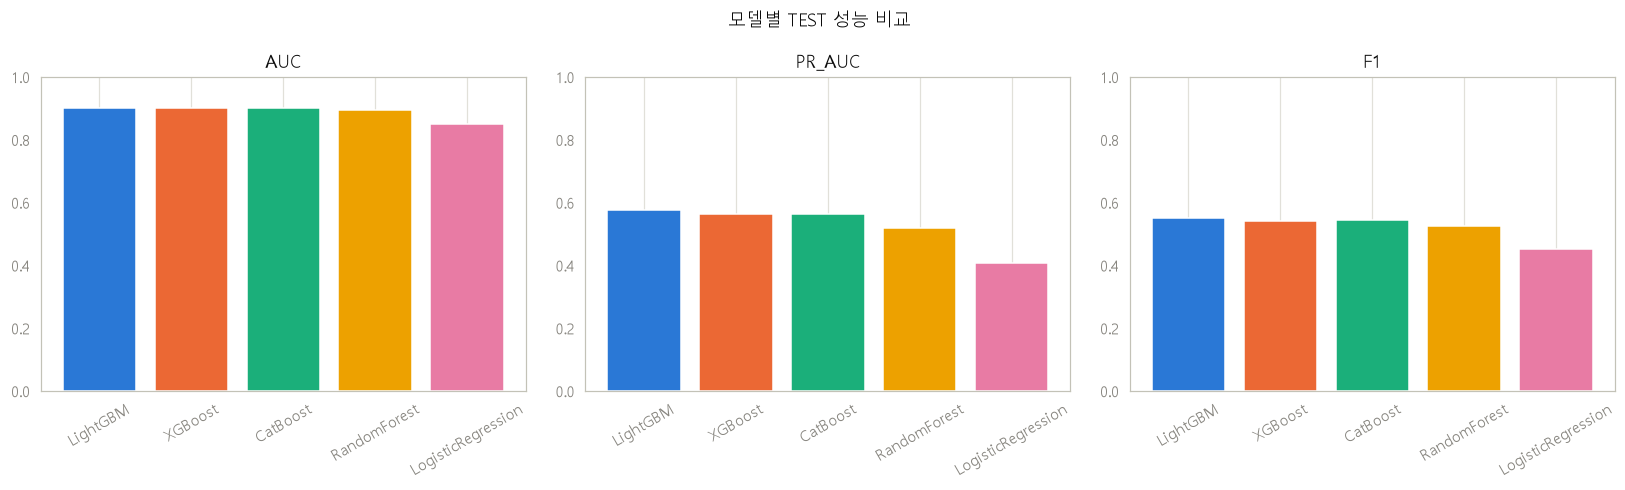

In [15]:
metrics_to_plot = ["auc", "pr_auc", "f1"]
models_order = test_results.index.tolist()

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(15, 4.5))
for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(models_order, test_results.loc[models_order, metric], color=PALETTE[: len(models_order)])
    ax.set_title(metric.upper())
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y")
    ax.set_axisbelow(True)

fig.suptitle("모델별 TEST 성능 비교")
plt.tight_layout()
plt.show()

In [16]:
# ------------------------------------------------------------------
# 해석 시 주의할 점 + 최종 모델 채택
# 1. LogLoss는 이 표에서 직접 비교하기에 부적절하다: LightGBM은 클래스 재조정 없이 학습했지만
#    XGBoost(scale_pos_weight)/CatBoost(auto_class_weights)/RandomForest·LogisticRegression
#    (class_weight="balanced")은 전부 재조정해서 학습했다. 그 결과 valid F1-최적 threshold도
#    LightGBM(~0.35)과 나머지(~0.7~0.9, 아래 확인)가 크게 달라 확률 스케일 자체가 다르고,
#    스케일에 민감한 LogLoss는 이 차이의 영향을 받는다. AUC/PR-AUC/F1은 threshold·스케일에
#    덜 민감해 모델 간 비교에 더 적합하다.
# 2. 모델 선택은 AUC 하나가 아니라 PR-AUC, F1, 학습시간, 해석 가능성을 함께 고려한다.
# 3. test 결과는 최종 비교 보고용이며, 이 결과를 보고 하이퍼파라미터를 다시 조정하지 않는다.
# 4. 이후 SHAP/LTV 분석에는 저장된 LightGBM을 사용하되, 모델 비교 결과와 선택 근거를 함께 기록한다.
# ------------------------------------------------------------------
print("VALID PR-AUC 순위:")
print(
    results_df[results_df["split"] == "valid"]
    .sort_values("pr_auc", ascending=False)
    [["model", "auc", "pr_auc", "threshold", "precision", "recall", "f1"]]
    .round(4)
    .to_string(index=False)
)
print("\n모델 비교 완료: test 결과를 확인한 뒤 추가 튜닝하지 않는다.")

VALID PR-AUC 순위:
             model    auc  pr_auc  threshold  precision  recall     f1
          LightGBM 0.8986  0.5736     0.2716     0.5366  0.5611 0.5486
           XGBoost 0.8963  0.5623     0.8429     0.5305  0.5465 0.5384
          CatBoost 0.8976  0.5616     0.8552     0.5464  0.5422 0.5443
      RandomForest 0.8904  0.5213     0.8024     0.4971  0.5548 0.5244
LogisticRegression 0.8470  0.4042     0.8133     0.3927  0.5204 0.4476

모델 비교 완료: test 결과를 확인한 뒤 추가 튜닝하지 않는다.
